# Evolutionary Algorithm demonstration

## Introduction

This jupyter notebook illustrates how Evolutionary Algorithm can be used to solve the vertex coloring problem.

**[The problem:](https://en.wikipedia.org/wiki/Graph_coloring)**  
The vertex coloring (graph coloring) problem is a well-known mathematical puzzle. For a given graph, one has to find the least amount of colours for vertices, where no 2 connected vertices share the same colour.

**Graph types:**  
In this notebook, both [bipartite](https://en.wikipedia.org/wiki/Bipartite_graph) and random graphs will be analyzed and the algorithm will have to find the optimal solution for both of them.


## Setup

First, the class representing the graph, on which the vertex coloring problem will be illustrated has to be defined. I've decided to include the additional option to draw the graph, which will allow us to visualize the problem and the solutions to it later on.

In [9]:
from enum import Enum
from typing import cast, Optional
import random
import numpy as np
import math
import matplotlib.pyplot as plt

vertex_list = list[int]
edge = tuple[int, int]

class GraphType(Enum):
    BIPARTITE = "bipartite"
    RANDOM = "random"

class Graph:
    def __init__(self,
                 vertices: vertex_list = [],
                 edges: list[edge] = [],
                 U: vertex_list = [],
                 V: vertex_list = []) -> None:
        self.vertices: vertex_list = vertices
        self.edges: list[edge] = edges
        self.U: vertex_list = U
        self.V: vertex_list = V

    def _append_edges(self, edges: list[edge]) -> None:
        for edge in edges:
            self.edges.append(edge)

    def bipartite(self, N: int) -> None:
        split_value = random.randint(5, N - 4)
        edges: list[edge] = []
        for vertex_1 in range(1, N + 1):
            self.vertices.append(vertex_1)
            if vertex_1 <= split_value:
                self.U.append(vertex_1)
                for _ in range(0, 2):
                    random_vertex = random.randint(split_value + 1, N)
                    if vertex_1 != random_vertex:
                        edges.append((vertex_1, random_vertex))
            else:
                self.V.append(vertex_1)
                for _ in range(0, 2):
                    random_vertex = random.randint(1, split_value - 1)
                    if vertex_1 != random_vertex: edges.append((vertex_1, random_vertex))
        sorted_edges = [cast(edge, tuple(sorted(e))) for e in edges]
        self._append_edges(list(set(sorted_edges)))

    def random(self, N: int) -> None:
        for vertex in range(1, N + 1): self.vertices.append(vertex)
        graph_density = 0.3
        edges: list[edge] = []
        while (len(edges) / ((N ** 2 - N) / 2)) <= graph_density:
            r1, r2 = random.randint(1, N), random.randint(1, N)
            if r1 != r2:
                edges.append(cast(tuple[int,int], tuple(sorted((r1, r2)))))
        self._append_edges(list(set(edges)))

    def draw(self, title: str = "Graph", individual: Optional[list[int]]=None):
        plt.figure(figsize=(10, 10))
        pos: dict[int, tuple[float, float]] = {}

        if self.U and self.V:  # bipartite
            n_U = len(self.U)
            y_coords_U = [-(i / (n_U - 1)) if n_U > 1 else 0 for i in range(n_U)]
            for v, y in zip(self.U, y_coords_U):
                pos[v] = (0, y)

            n_V = len(self.V)
            y_coords_V = [-(i / (n_V - 1)) if n_V > 1 else 0 for i in range(n_V)]
            for v, y in zip(self.V, y_coords_V):
                pos[v] = (1, y)
        else:  # random
            n = len(self.vertices)
            radius = 5
            for i, v in enumerate(self.vertices):
                angle = 2 * math.pi * i / n
                pos[v] = (radius * math.cos(angle), radius * math.sin(angle))

        if individual is not None:
            unique_colors = set(individual)
            color_map = {c: (random.random(), random.random(), random.random()) for c in unique_colors}
            vertex_colors = [color_map[c] for c in individual]
        else:
            vertex_colors = ['skyblue' for _ in self.vertices]

        for u, v in self.edges:
            if individual is not None:
                c1 = np.array(vertex_colors[u-1])
                c2 = np.array(vertex_colors[v-1])
                if individual[u-1] == individual[v-1]:
                    edge_color = 'red'
                else:
                    edge_color = tuple((c1 + c2) / 2)
            else:
                edge_color = 'gray'

            x_values = [pos[u][0], pos[v][0]]
            y_values = [pos[u][1], pos[v][1]]
            plt.plot(x_values, y_values, color=edge_color, zorder=1)

        for v, (x, y) in pos.items():
            idx = self.vertices.index(v)
            plt.scatter(x, y, s=300, color=vertex_colors[idx], edgecolor='black', zorder=2)
            plt.text(x, y, str(v), ha='center', va='center', fontsize=10, zorder=3)

        plt.title(title)
        plt.axis('off')
        plt.show()

The next element is the Graph Colorizer. This is the class that actually implements the Evolutionary Algorithm and that handles the logic necessary for finding the solution to the problem. Both the optimal and random initiation have been implemented, but only the random one will be used, as it allows for the best visualization of the improvement that the algorithm makes (as the optimalization is more visible in the case of using this initiation method).

In [10]:
from tqdm import tqdm
from matplotlib.ticker import MaxNLocator


single_individual = list[int]
individual_with_fitness = tuple[list[int], int]
population = list[single_individual]


class InitializationMode(Enum):
    GREEDY = "greedy"
    RANDOM = "random"


class GraphColorizer:
    def __init__(self,
                 max_iterations: int,
                 population_size: Optional[int],
                 mutation_prob: float,
                 crossover_prob: float,
                 initialization_mode: Optional[InitializationMode]=None,
                 graph_type: Optional[GraphType] = None,
                 n_vertices: Optional[int] = None,
                 graph: Optional[Graph] = None,
                 initial_population: Optional[population]=None):
        if graph is not None:
            self.graph = graph
        else:
            assert graph_type is not None
            assert n_vertices is not None
            self.graph = self._load_graph(graph_type=graph_type, n_vertices=n_vertices)
        self.max_iterations = max_iterations
        if population_size is not None:
            self.population_size = population_size
        else:
            assert initial_population is not None
            self.population_size = len(initial_population[0])
        self.mutation_probability = mutation_prob
        self.crossover_probability = crossover_prob
        self.number_of_vertices = len(self.graph.vertices)
        self.population = initial_population
        self.initialization_mode = initialization_mode

    @staticmethod
    def _load_graph(graph_type: GraphType, n_vertices: int = 25) -> Graph:
        g = Graph()
        if graph_type == GraphType.BIPARTITE:
            g.bipartite(n_vertices)
        else:
            g.random(n_vertices)
        return g

    def _initialize_population(self) -> tuple[population, list[int]]:
        """Create the initial population. We randomly choose as many
        individuals as is set in self.population_size.
        Create population. Each individual consists of sequence of integers, where a
        sequence position 1, 2, ..., n represents the number of vertex, and the value
        (integer) of the sequence on the position n represents the color of the vertex n
        The initial population consists only of valid individuals
        (connected vertices of different colors).

        :return: A tuple of two lists: the first list contains the individuals, and the second list contains
        available colors at the start.
        """
        population: list[single_individual] = []
        for _ in range(self.population_size):
            individual: single_individual = [-1] * self.number_of_vertices

            vertices = list(range(self.number_of_vertices))
            random.shuffle(vertices)  # ważne dla losowości
            assert self.initialization_mode is not None

            for vertex in vertices:
                used_colours: set[int] = set()

                for u, v in self.graph.edges:
                    if u - 1 == vertex and individual[v - 1] != -1:
                        used_colours.add(individual[v - 1])
                    if v - 1 == vertex and individual[u - 1] != -1:
                        used_colours.add(individual[u - 1])

                if self.initialization_mode == InitializationMode.GREEDY:
                    color = 0
                    while color in used_colours:
                        color += 1
                    individual[vertex] = color

                elif self.initialization_mode == InitializationMode.RANDOM:
                    available_colours = [
                        c for c in range(self.number_of_vertices)
                        if c not in used_colours
                    ]
                    individual[vertex] = random.choice(available_colours)

            population.append(individual)
        return population, list(range(self.number_of_vertices))


    def _fitness_score(self, individual: single_individual) -> int:
        conflicts = 0

        for (u, v) in self.graph.edges:
            if individual[u-1] == individual[v-1]:
                conflicts += 1

        colors_used = len(set(individual))

        return colors_used + 1_000 * (conflicts ** 2)


    def _selection(self, population_with_fitness: list[individual_with_fitness]) -> individual_with_fitness:
        i1, i2 = random.sample(population_with_fitness, 2)
        return i1 if i1[1] < i2[1] else i2


    def _crossover(self, parent1: single_individual, parent2: single_individual) -> tuple[single_individual, single_individual]:
        if random.random() > self.crossover_probability:
            return parent1.copy(), parent2.copy()

        point = random.randint(1, self.number_of_vertices - 1)

        child1 = parent1[:point] + parent2[point:]
        child2 = parent2[:point] + parent1[point:]

        return child1, child2

    def _mutation(self, individual: single_individual):
        if random.random() < self.mutation_probability:
            gene = random.randint(0, self.number_of_vertices - 1)
            individual[gene] = random.randint(0, self.number_of_vertices - 1)

    def run(self) -> tuple[single_individual, list[int]]:
        if self.population is None:
            self.population, _ = self._initialize_population()
        best_overall: Optional[tuple[single_individual, int]] = None
        history: list[int] = []

        if self.max_iterations == 0:
            population_with_fitness = [(individual, self._fitness_score(individual)) for individual in self.population]
            best_in_generation = min(population_with_fitness, key=lambda x: x[1])
            return best_in_generation[0], []

        for iteration in tqdm(range(self.max_iterations), desc="GA Progress"):
            population_with_fitness = [(individual, self._fitness_score(individual)) for individual in self.population]
            best_in_generation = min(population_with_fitness, key=lambda x: x[1])
            history.append(best_in_generation[1])
            if best_overall is None or best_in_generation[1] < best_overall[1]:
                best_overall = best_in_generation

            new_population: list[single_individual] = []
            while len(new_population) < self.population_size:
                parent1 = self._selection(population_with_fitness)
                parent2 = self._selection(population_with_fitness)

                if random.random() < self.crossover_probability:
                    child1, child2 = self._crossover(parent1[0], parent2[0])
                else:
                    child1, child2 = parent1[0][:], parent2[0][:]

                self._mutation(child1)
                self._mutation(child2)

                new_population.extend([child1, child2])
            self.population = new_population[:self.population_size]
            # if iteration % 5_000 == 0:
            #     print(f"Iteration #{iteration}, best: {best_overall[1]}")

        assert best_overall is not None
        return best_overall[0], history

To visualize the optimalization process, it is good to define a function that allows the user to compress the history to a list of tuples, where the same values are compressed to one element. The amount of elements compressed is the second member of the tuple.

In [11]:
from itertools import groupby
from typing import Iterable

def compress_runs(data: Iterable[int]) -> list[tuple[int, int]]:
    return [(key, len(list(group))) for key, group in groupby(data)]

compress_runs([1,1,1,2,1,2,2,3])

[(1, 3), (2, 1), (1, 1), (2, 2), (3, 1)]

Now, another useful function for visualizing the evolution will be defined. It allows the user to see, how optimal the algorithm's solutions were along the way

In [12]:
def plot_history(data: Iterable[int], title: str = "Optimization progress"):
    data = np.array(data)
    cum_min = np.minimum.accumulate(data)

    plt.figure()
    plt.plot(data, label="best_in_generation")
    plt.plot(cum_min, linestyle='--', label="best_overall")

    plt.xlabel("Iteration")
    plt.ylabel("Fitness")
    plt.title("Optimization progress")
    plt.legend()
    plt.grid(True)
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()

To minimize the length of the code called later on, a function that calls the Graph Colorizer and the specific methods for graphing its progression and final outcome will be defined.

In [13]:
def call_colonizer(max_iterations: int,
                   mutation_prob: float,
                   crossover_prob: float,
                   initialization_mode: Optional[InitializationMode]=None,
                   population_size: Optional[int]=None,
                   graph_type: Optional[GraphType]=None,
                   n_vertices: Optional[int]=None,
                   graph: Optional[Graph]=None,
                   show_graph: bool=False,
                   show_history: bool=False,
                   initial_population: Optional[population]=None) -> GraphColorizer:

    colonizer = GraphColorizer(max_iterations,
                               population_size,
                               mutation_prob,
                               crossover_prob,
                               initialization_mode,
                               graph_type,
                               n_vertices,
                               graph,
                               initial_population)

    best, history = colonizer.run()
    print(f"Best solution: {len(set(best))}")
    print(f"Solution: {best}")
    print(f"History: {compress_runs(history)}")

    if show_graph:
        assert graph is not None
        graph.draw(individual=best)
    if show_history:
        plot_history(history)
    return colonizer

I will define the graphs, which the algorithm will try to find the solution to. Defining single bipartite and random graphs and reusing them will make the comparison of different hyperparameters' values possible, as the graphs will remain the same for all GraphColorizers defined.  
The graphs will be defined with pre-set parameters to ensure as little randomness as possible is present when re-running the experiments described in the notebook.

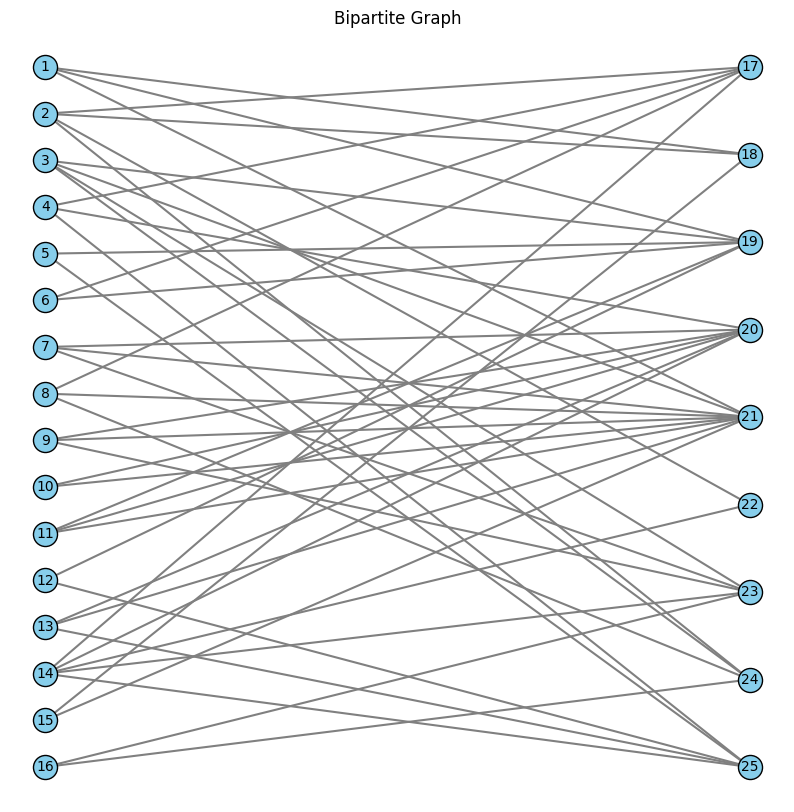

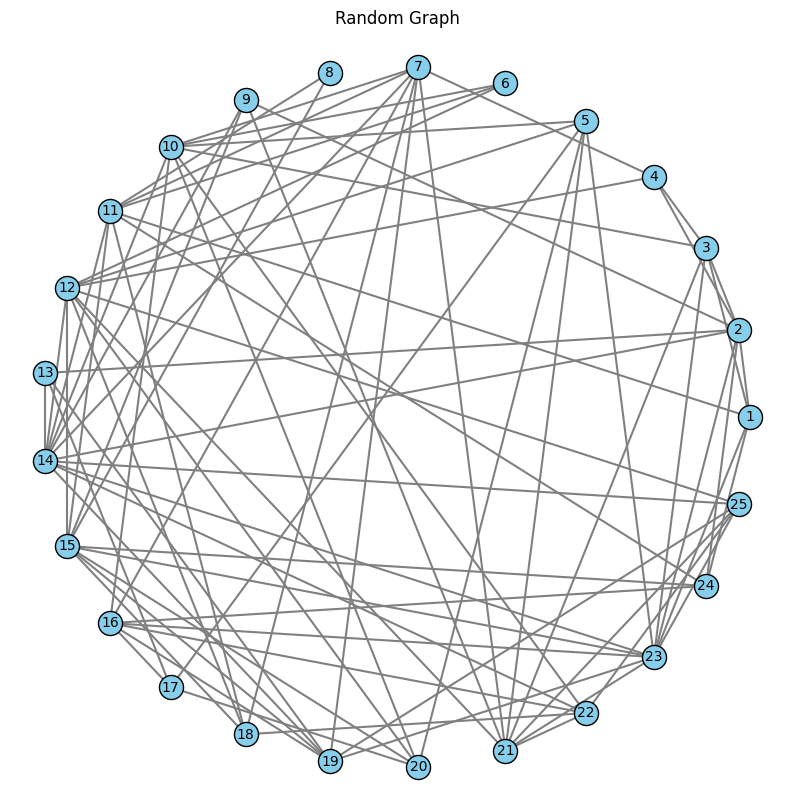

In [14]:
graph_bipartite = Graph(
    vertices=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25],
    edges=[(15, 21), (7, 23), (7, 20), (12, 19), (3, 19), (14, 25), (12, 25), (14, 22), (5, 19), (5, 25), (8, 21), (9, 20), (8, 24), (10, 21), (9, 23), (11, 20), (2, 17), (1, 18), (1, 21), (13, 20), (6, 17), (13, 21), (4, 17), (3, 21), (4, 20), (3, 24), (8, 17), (11, 19), (10, 20), (2, 22), (16, 24), (7, 21), (6, 19), (13, 25), (14, 17), (3, 23), (14, 23), (14, 20), (4, 25), (9, 21), (11, 21), (2, 18), (1, 19), (15, 18), (2, 24), (16, 23)],
    U=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
    V=[17, 18, 19, 20, 21, 22, 23, 24, 25]
)

graph_random = Graph(
    vertices=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25],
    edges=[(5, 10), (12, 25), (14, 22), (23, 25), (11, 14), (13, 17), (6, 11), (7, 10), (1, 24), (15, 23), (16, 22), (7, 19), (12, 18), (5, 12), (8, 11), (5, 21), (2, 4), (10, 20), (13, 19), (16, 24), (7, 21), (12, 20), (5, 23), (9, 21), (10, 22), (15, 18), (16, 17), (7, 14), (3, 10), (21, 25), (14, 19), (9, 14), (1, 3), (13, 14), (16, 19), (7, 16), (12, 15), (22, 25), (3, 21), (2, 13), (1, 23), (14, 23), (3, 23), (11, 18), (7, 11), (2, 24), (16, 23), (21, 22), (14, 25), (8, 15), (15, 20), (12, 21), (1, 2), (17, 20), (10, 14), (1, 11), (6, 10), (7, 18), (12, 14), (5, 20), (2, 3), (10, 16), (11, 15), (11, 24), (6, 12), (15, 24), (3, 4), (4, 12), (2, 14), (2, 23), (18, 22), (19, 23), (15, 19), (4, 7), (21, 23), (5, 17), (9, 15), (2, 9), (19, 25)]
)

graph_bipartite.draw("Bipartite Graph")
graph_random.draw("Random Graph")

## Experiments

### Bipartite

#### Iterations

In the beginning, lets focus on the bipartite graph, as it has the trivial solution of 2, regardless of the specific edges. This means that we will know exactly, how far the algorithm is from the optimal solution. Let's display the initial population that the algorithm will be working with. Copies of the same population will be reused to provide the experiments with the same initial conditions.

Best solution: 13
Solution: [11, 21, 19, 0, 11, 6, 1, 10, 4, 24, 19, 21, 4, 11, 0, 1, 24, 8, 13, 9, 2, 0, 24, 9, 13]
History: []


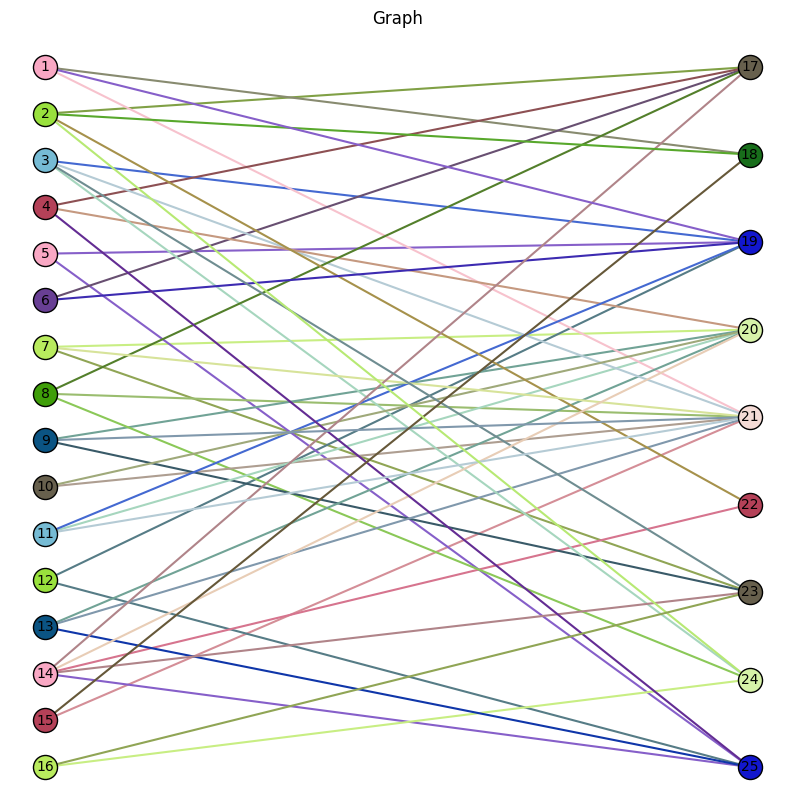

In [15]:
colonizer = call_colonizer(
    max_iterations=0,
    population_size=100,
    mutation_prob=.1,
    crossover_prob=.7,
    graph=graph_bipartite,
    initialization_mode=InitializationMode.RANDOM,
    show_graph=True
)

population_bipartite: population = cast(population, colonizer.population)

It is apparent that the first generated solution is not optimal at all. The current solution is very far from the desired score of 2. I will run the first simulation on 1000 iterations and pretty standard mutation and crossover probabilities.

GA Progress: 100%|██████████| 1000/1000 [00:00<00:00, 4978.60it/s]


Best solution: 6
Solution: [16, 11, 3, 15, 3, 8, 15, 3, 1, 3, 1, 8, 3, 8, 1, 15, 16, 8, 15, 16, 11, 1, 11, 16, 1]
History: [(13, 1), (14, 10), (13, 13), (12, 13), (11, 23), (10, 24), (9, 1), (10, 5), (9, 403), (8, 78), (7, 1), (8, 79), (7, 320), (6, 2), (7, 27)]


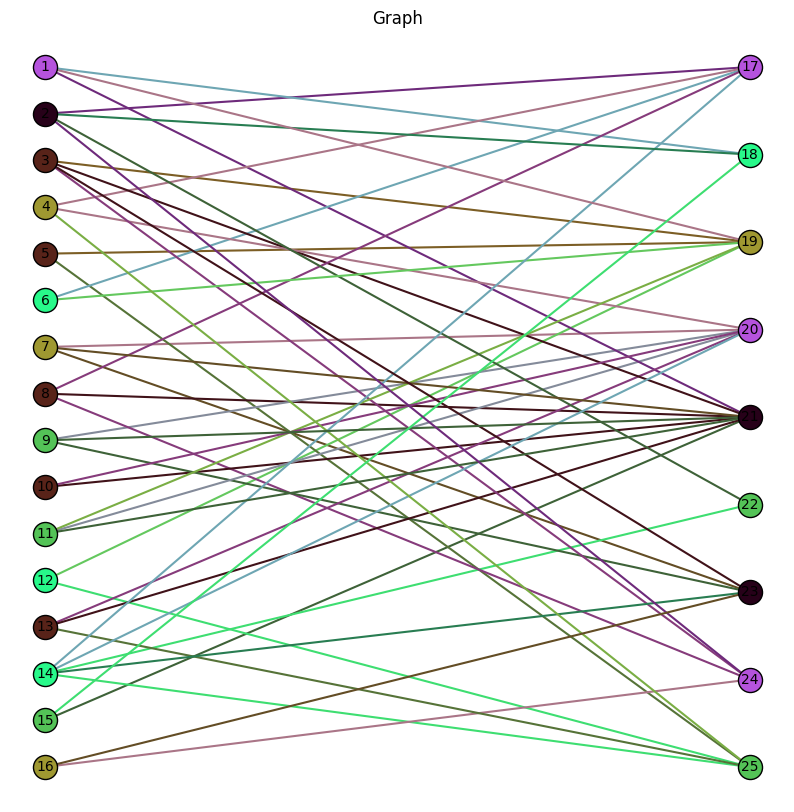

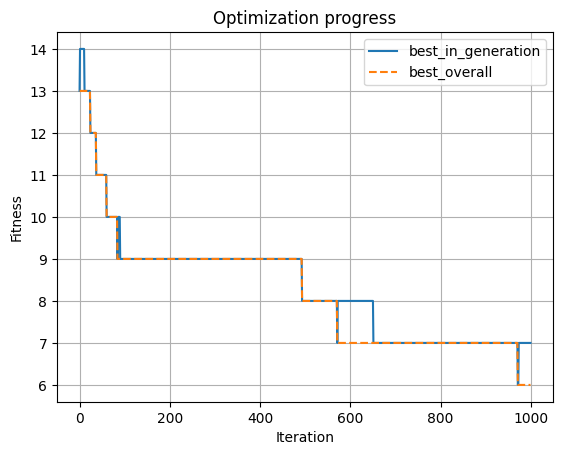

In [16]:
call_colonizer(
    max_iterations=1_000,
    mutation_prob=.1,
    crossover_prob=.7,
    graph=graph_bipartite,
    show_graph=True,
    show_history=True,
    initial_population=population_bipartite[:]
);

We may observe that the solution has been drastically improved, though it is still pretty far from 2. A simulation ran with a higher iteration count may improve the outcome even more.

GA Progress: 100%|██████████| 100000/100000 [00:19<00:00, 5122.12it/s]


Best solution: 3
Solution: [22, 13, 13, 13, 22, 22, 13, 22, 13, 13, 22, 13, 22, 22, 13, 13, 2, 2, 2, 2, 2, 2, 2, 2, 2]
History: [(13, 2), (14, 2), (13, 3), (16, 1), (14, 3), (13, 3), (12, 12), (11, 34), (10, 88), (9, 2), (10, 7), (9, 153), (8, 200), (7, 1043), (6, 1), (7, 61), (6, 1332), (5, 22457), (4, 1), (5, 55), (4, 1061), (3, 73479)]


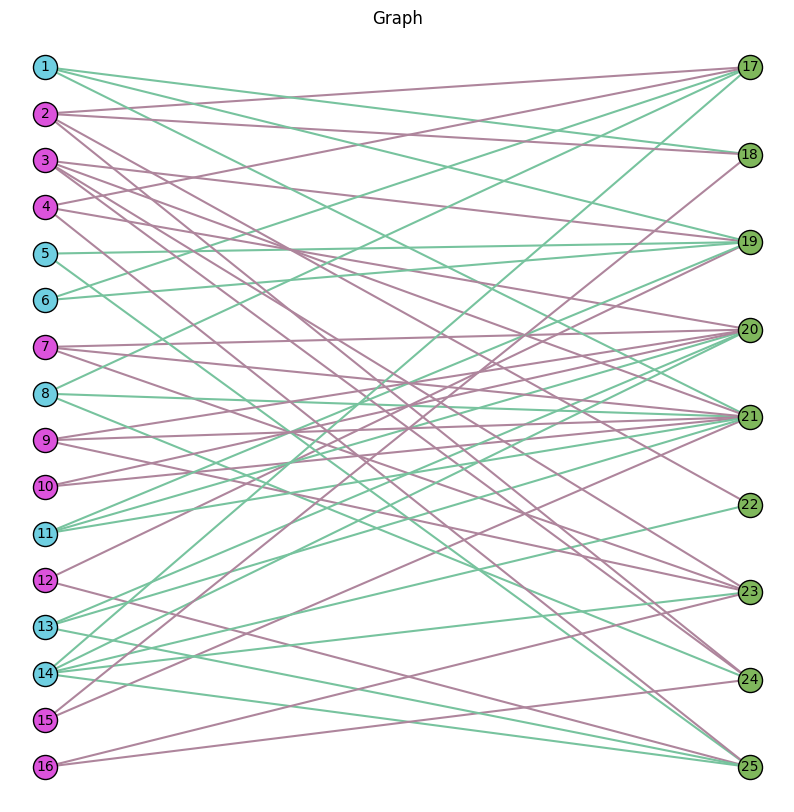

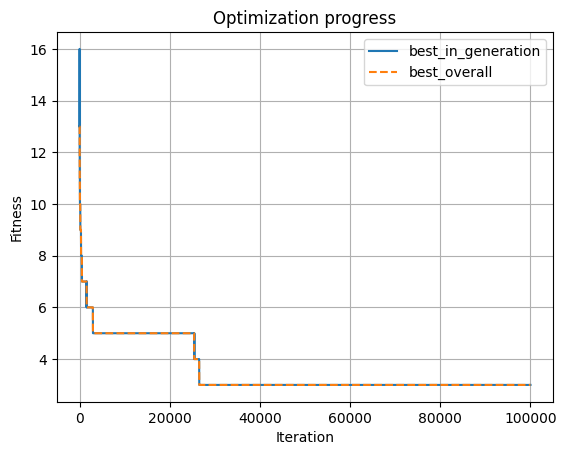

In [17]:
call_colonizer(
    max_iterations=100_000,
    mutation_prob=.1,
    crossover_prob=.7,
    graph=graph_bipartite,
    show_graph=True,
    show_history=True,
    initial_population=population_bipartite[:]
);

With the iteration count of 100_000, the simulation finally managed to find the correct solution. From observing the optimization process graph, we may conclude that the correct individual was found at about 90_000th iteration.

#### Mutation

One of the crucial parts of the Evolutionary Algorithm is the chance of mutation. In the following experiment we will observe, how the algorithm behaves when no mutation is present.

GA Progress: 100%|██████████| 100000/100000 [01:18<00:00, 1275.88it/s]


Best solution: 11
Solution: [8, 11, 1, 13, 16, 8, 17, 3, 17, 1, 7, 11, 3, 8, 1, 18, 16, 7, 15, 18, 15, 3, 0, 17, 7]
History: [(13, 9), (12, 10), (11, 99981)]


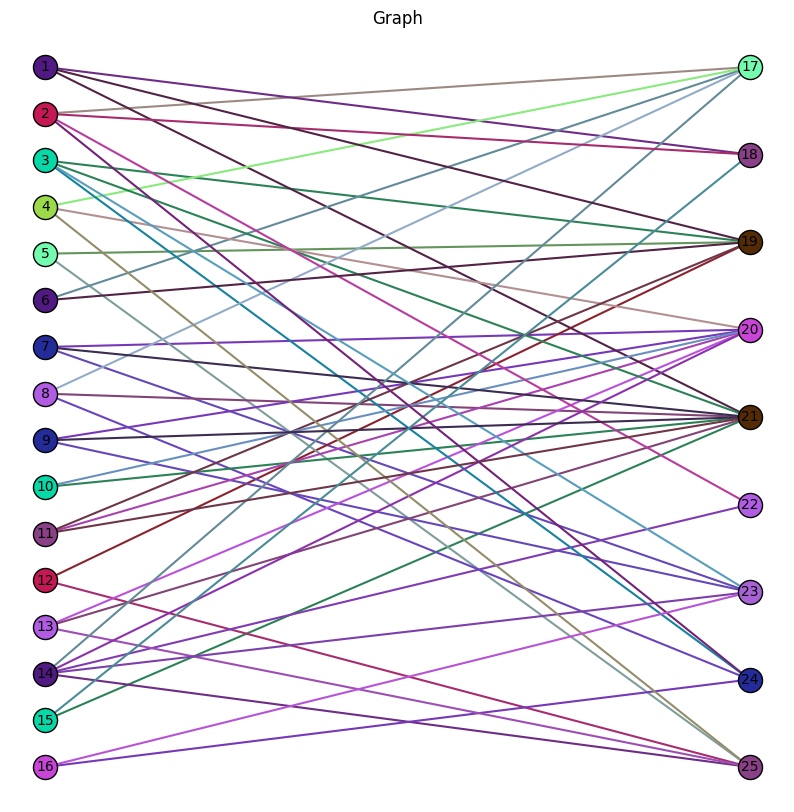

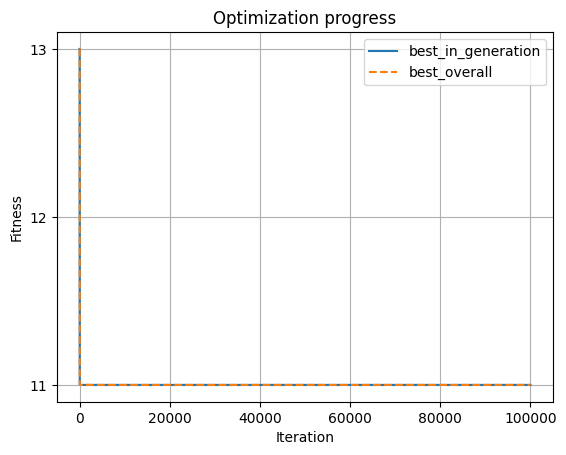

In [18]:
call_colonizer(
    max_iterations=100_000,
    population_size=100,
    mutation_prob=0,
    crossover_prob=.7,
    graph=graph_bipartite,
    show_graph=True,
    show_history=True,
    initial_population=population_bipartite
);

The outcome is extremely interesting. Without the chance of mutation, the algorithm almost immediately found the most optimal solution that was accessible for it and did not improve at all until the end. When no mutation is present, there is no way of finding some solutions, as the algorithm can only exchange the given parameters between parents and cannot ever generate new ones, which caps its potential.  

This experiment was an extreme example though. I will run the function with a very small chance of mutation and we will observe the outcome.

GA Progress: 100%|██████████| 100000/100000 [01:16<00:00, 1311.16it/s]


Best solution: 4
Solution: [0, 0, 4, 4, 4, 4, 21, 0, 0, 21, 4, 4, 0, 4, 4, 21, 21, 21, 12, 12, 12, 12, 12, 12, 12]
History: [(13, 4), (12, 6), (11, 1), (10, 3), (9, 11), (8, 23), (7, 18750), (6, 11370), (5, 1967), (4, 67865)]


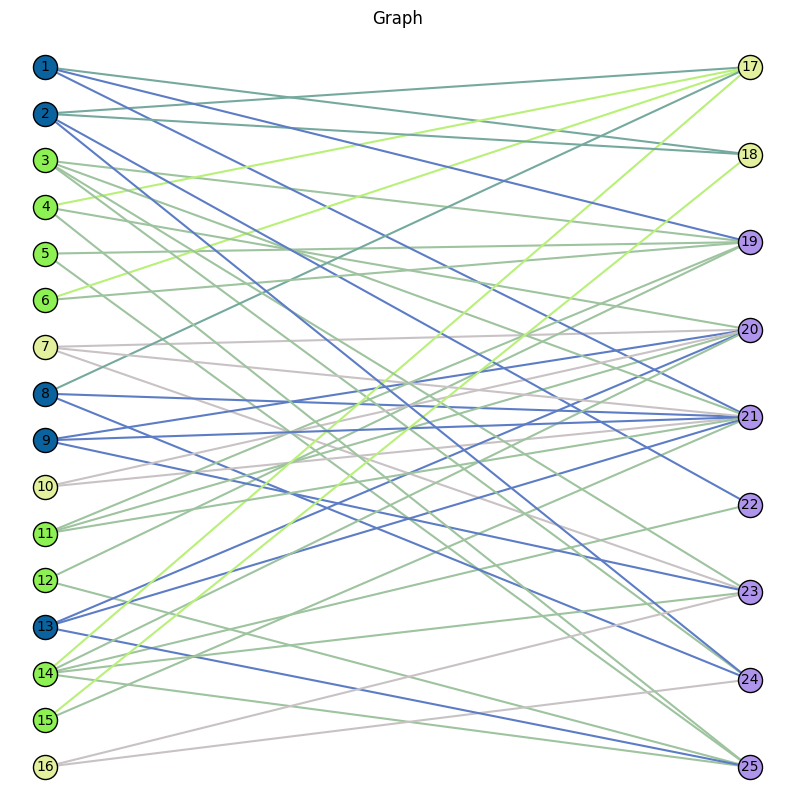

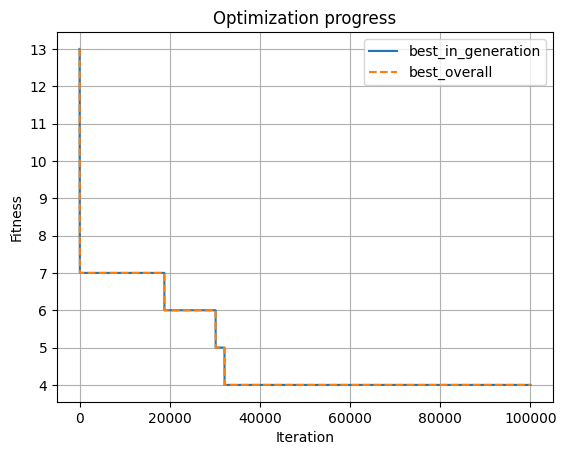

In [19]:
call_colonizer(
    max_iterations=100_000,
    population_size=100,
    mutation_prob=0.01,
    crossover_prob=.7,
    graph=graph_bipartite,
    show_graph=True,
    show_history=True,
    initial_population=population_bipartite
);

As we can see - with a small mutation chance, the algorithm's optimization can take much longer. It is possible that with much more iterations it could find the optimal one, but the main takeaway from this simulation is that a low mutation chance can cause the evolutionary algorithm to become much slower.
The following experiment will explore the other side of the spectrum - it will show, what a very high mutation chance can cause.

GA Progress: 100%|██████████| 100000/100000 [01:30<00:00, 1103.03it/s]


Best solution: 4
Solution: [4, 16, 4, 4, 4, 24, 4, 4, 16, 16, 4, 16, 4, 4, 4, 16, 3, 24, 3, 3, 3, 24, 3, 3, 3]
History: [(13, 2), (12, 2), (13, 1), (12, 9), (11, 2), (12, 1), (11, 3), (10, 1), (11, 1), (10, 3), (11, 1), (10, 1), (11, 3), (10, 5), (9, 1), (10, 5), (9, 1), (8, 1), (9, 3), (10, 1), (9, 5), (8, 3), (9, 2), (8, 2), (9, 2), (8, 4), (9, 1), (8, 9), (9, 1), (8, 1), (9, 1), (8, 1), (9, 2), (8, 2), (9, 1), (8, 4), (9, 1), (7, 1), (8, 6), (9, 1), (8, 1), (9, 1), (8, 6), (7, 3), (8, 1), (7, 4), (8, 8), (9, 1), (8, 2), (9, 1), (8, 3), (9, 3), (8, 3), (9, 1), (7, 1), (8, 12), (9, 3), (8, 2), (9, 1), (8, 2), (9, 4), (8, 9), (7, 1), (8, 1), (9, 1), (8, 9), (7, 1), (8, 2), (7, 2), (8, 6), (9, 7), (8, 1), (9, 4), (10, 1), (9, 5), (10, 2), (9, 9), (8, 6), (9, 2), (8, 3), (7, 5), (6, 2), (7, 1), (8, 1), (7, 8), (8, 1), (7, 4), (8, 1), (7, 1), (8, 3), (7, 3), (6, 1), (7, 1), (6, 3), (7, 2), (6, 1), (7, 5), (6, 3), (7, 1), (6, 2), (7, 2), (8, 1), (7, 8), (8, 1), (7, 2), (8, 1), (7, 1), (8, 

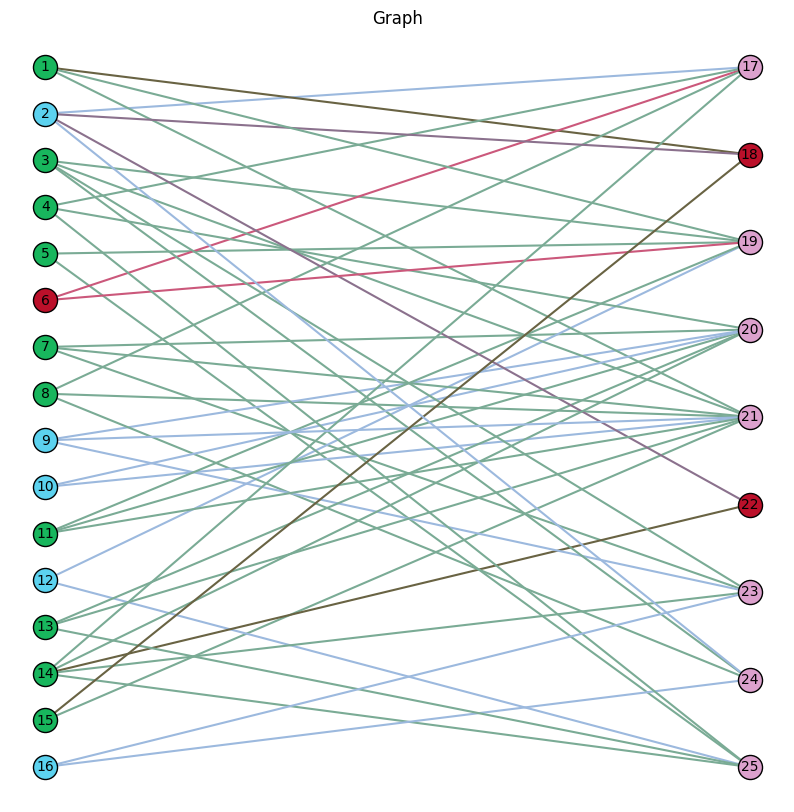

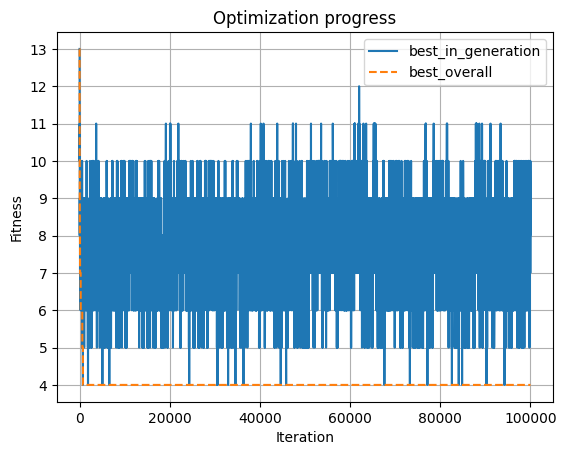

In [20]:
call_colonizer(
    max_iterations=100_000,
    population_size=100,
    mutation_prob=0.9,
    crossover_prob=.7,
    graph=graph_bipartite,
    show_graph=True,
    show_history=True,
    initial_population=population_bipartite
);

As we see - the best_overall solution was not terrible, but we do not see the improvement in best_in_generation over time. The algorithm becomes almost completely random and the average best_in_generation remains roughly the same between iterations, as the correct patterns found by it cannot be reliably passed on to new generations.

#### Crossover

Another extremely important hyperparameter is the rate of crossover happenning. Let's start with turning this mechanism off completely.

GA Progress: 100%|██████████| 100000/100000 [00:18<00:00, 5362.10it/s]


Best solution: 4
Solution: [11, 19, 11, 19, 19, 11, 13, 19, 13, 13, 11, 19, 19, 19, 11, 19, 24, 13, 24, 24, 24, 11, 24, 24, 11]
History: [(13, 7), (12, 4), (11, 1), (12, 14), (11, 9), (10, 107), (9, 71), (8, 163), (7, 1), (8, 152), (7, 457), (6, 1233), (5, 28228), (4, 69553)]


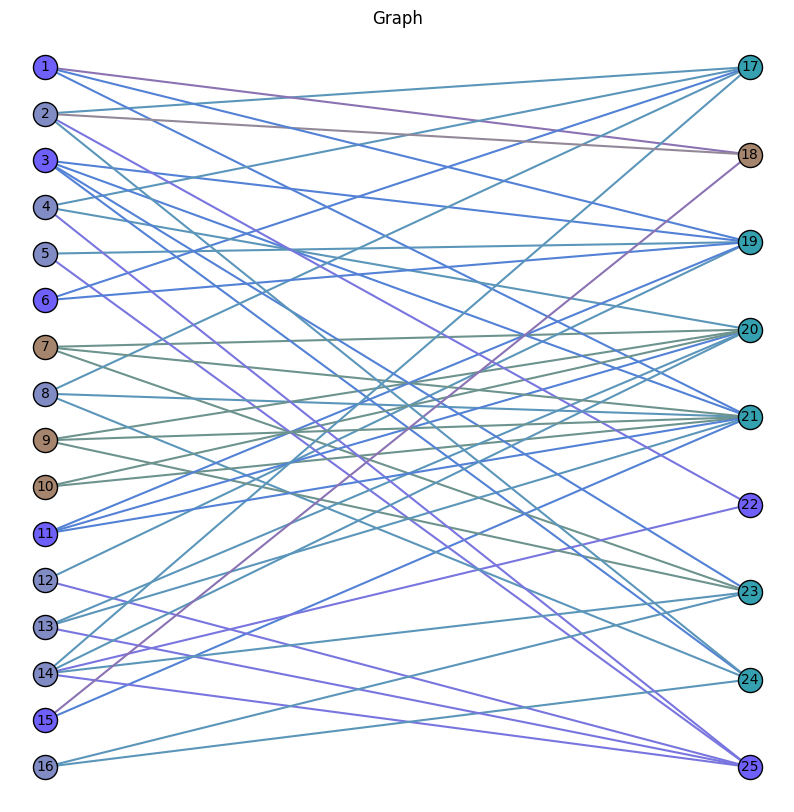

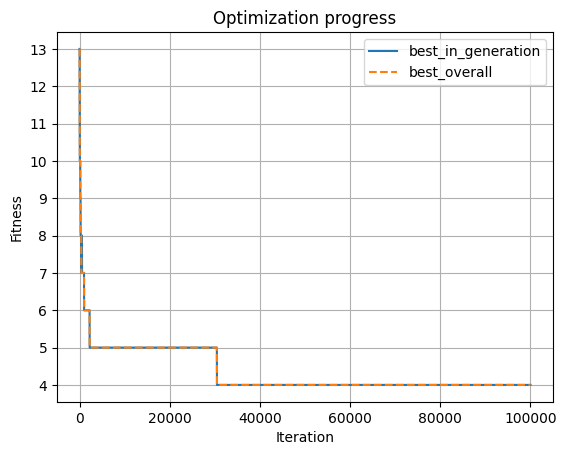

In [21]:
call_colonizer(
    max_iterations=100_000,
    mutation_prob=.1,
    crossover_prob=0,
    graph=graph_bipartite,
    show_graph=True,
    show_history=True,
    initial_population=population_bipartite[:]
);

Apparently, removing crossover completely did not have a horrible impact on our simulation. It did slightly worsen its progression, but compared to removing mutation, it is much less impactful.

Now, we will increase the crossover probability to 99% and observe the outcome.

GA Progress: 100%|██████████| 100000/100000 [00:20<00:00, 4841.15it/s]


Best solution: 4
Solution: [21, 24, 2, 2, 24, 24, 21, 21, 2, 24, 21, 2, 21, 21, 2, 2, 20, 20, 20, 20, 20, 20, 24, 20, 20]
History: [(13, 1), (14, 1), (13, 1), (14, 3), (12, 1), (14, 3), (13, 17), (12, 3), (11, 23), (10, 37), (9, 56), (8, 206), (7, 244), (6, 1735), (5, 13035), (4, 84634)]


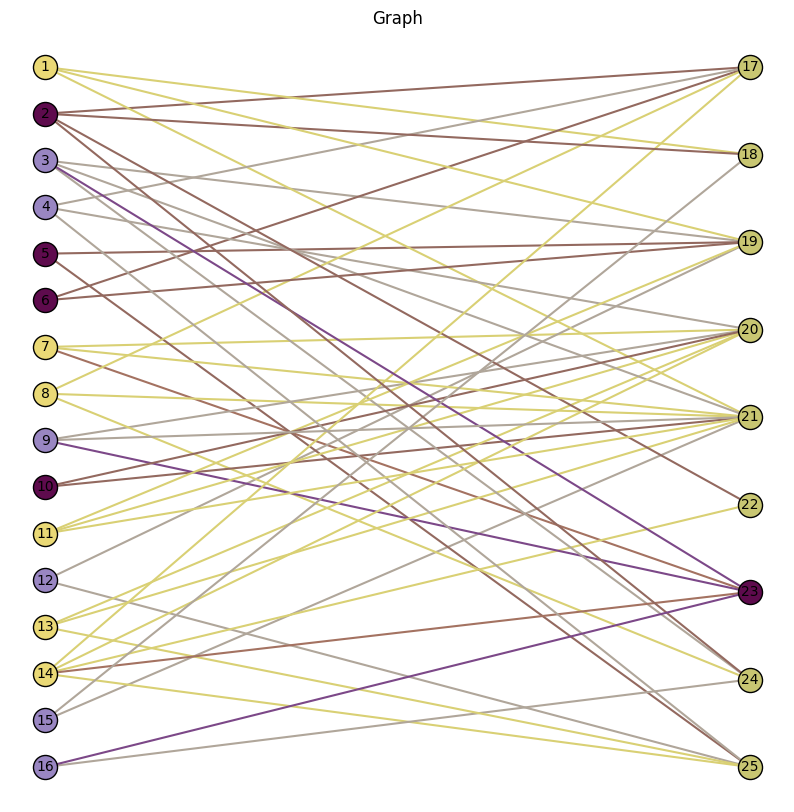

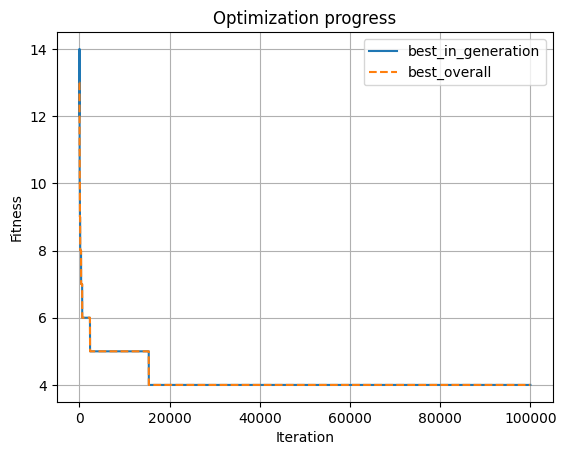

In [22]:
call_colonizer(
    max_iterations=100_000,
    mutation_prob=.1,
    crossover_prob=.99,
    graph=graph_bipartite,
    show_graph=True,
    show_history=True,
    initial_population=population_bipartite[:]
);